# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)
## Clase 4 — Matrices ralas y XGBoost

Competencia Kaggle: predecir si una reproducción es "abandono temprano" (`ms_played < 30000`). Métrica: ROC-AUC.

Este notebook parte de la **base mínima heredada** de las Clases 1–3 (carga, target, el feature set ganador y el esquema de validación, ya cerrados — sin repetir EDA ni las comparaciones intermedias, documentadas en esos notebooks) y dedica el cuerpo principal a la Clase 4: representar las categóricas como **matrices ralas** y reemplazar el árbol de decisión por **XGBoost** (boosting). La clase también introduce clustering (K-means) de forma conceptual/exploratoria, con un dataset de juguete (Boston) y sin bajarlo a código para el TP — queda **fuera de este notebook**, para cuando lo retomemos en la Clase 5.

## Base heredada de las Clases 1–3 (mínima)

Carga, target, las features derivadas de la Clase 1 (`content_type`, `hora`, `dia_semana`, `artista_top`), el esquema de validación temporal de la Clase 2 (test interno + CV de ventana expansiva) y el **feature set + hiperparámetros ganadores de la Clase 3** (`user_id`, `gap_min`, `bucket_count_30min`, árbol re-tuneado). Justificación completa de cada decisión en `tp_spotify_clase1_knn.ipynb`, `tp_spotify_clase2_arboles_2.ipynb` y `tp_spotify_clase3_atributos.ipynb` — acá solo el resultado.

Recortamos del `USECOLS` de la Clase 3 las columnas que solo servían para experimentos ya cerrados y **descartados** ahí (indicadores de missing, `offline_timestamp`, `episode_show_name`, `audiobook_*`, `album_name`): no forman parte de ninguna decisión vigente. Conservamos `master_metadata_track_name` porque lo vamos a necesitar más abajo, en el experimento de one-hot sin tope de esta clase.

**No repetimos el árbol de la Clase 3** para recalcular su AUC — ya lo tenemos documentado (CV 0.8232, `test_interno` 0.8093) y lo usamos como número fijo a superar.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import xgboost as xgb

from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "../competition_data"

# Estilo unico para todos los graficos del notebook (paleta validada para daltonismo).
C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

print("xgboost", xgb.__version__)

xgboost 3.2.0


In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_track_name", "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode", "user_id",
]
DTYPES = {
    "spotify_track_uri": "string", "spotify_episode_uri": "string", "audiobook_uri": "string",
}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES, low_memory=False)
train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)

print("Filas:", len(train_raw))
print("Proporcion de abandono temprano (target=1):", train_raw["target"].mean().round(4))
train_raw[["obs_id", "ms_played", "target"]].head()

Filas: 911344
Proporcion de abandono temprano (target=1): 0.278


,obs_id,ms_played,target
0,1,8956,1
1,2,202024,0
2,3,269480,0
3,4,24299,1
4,5,97877,0


In [3]:
# Cuatro derivadas ya cerradas (Clase 1: content_type, hora, dia_semana, artista_top).
train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(),
     train_raw["spotify_episode_uri"].notna(),
     train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)

ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))

col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(train_raw[col_artista].isin(TOP_ARTISTAS), "otros")

train_raw = train_raw.sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)

print("Features derivadas listas. artista_top:", train_raw["artista_top"].nunique(), "categorias (incluye 'otros').")

Features derivadas listas. artista_top: 51 categorias (incluye 'otros').


### Esquema de validación (Clase 2, sin repetir la búsqueda)

Mismo esquema cerrado en la Clase 2 y reusado en la Clase 3: **`test_interno`** (15% más reciente, se toca una única vez al final) y, dentro del 85% restante, **CV temporal de ventana expansiva** (4 folds, siempre pasado→futuro) para tomar todas las decisiones de este notebook. Nunca K-Fold aleatorio ni mezcla de épocas.

In [4]:
n = len(train_raw)
n_train = int(n * 0.85)
df_train = train_raw.iloc[:n_train].copy()
df_test_interno = train_raw.iloc[n_train:].copy()

for nombre, df in [("train", df_train), ("test interno", df_test_interno)]:
    print(f"{nombre:<13} {len(df):>7} filas | {df['ts_dt'].min().date()} -> {df['ts_dt'].max().date()} "
          f"| tasa abandono {df['target'].mean():.4f}")

train          774642 filas | 2013-10-29 -> 2023-05-26 | tasa abandono 0.2865
test interno   136702 filas | 2023-05-26 -> 2024-08-31 | tasa abandono 0.2298


In [5]:
# Las dos numericas que sobrevivieron la Clase 3 (gap_min, bucket_count_30min). Se calculan
# sobre train+test_interno concatenados para que la recencia de la primera fila de cada
# bloque respete el historial real del usuario (misma logica de la Clase 3).
full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])

gap = full.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
full["gap_min"] = gap.fillna(-1)  # -1 = primera reproduccion de ese usuario en el dataset
full["bucket_count_30min"] = full.groupby(["user_id", "ts"])["obs_id"].transform("size")

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]

print("gap_min y bucket_count_30min listos.")

gap_min y bucket_count_30min listos.


### Feature set y receta ganadora (Clase 3, número fijo a superar)

`CAT_FINAL` son las categóricas de las Clases 1–2 más `user_id` (arbitrado en la Clase 3); `NUM_FINAL` son las dos numéricas que sobrevivieron el catálogo de técnicas de la Clase 3. `VENTANA_TRAIN_MESES=24` es la ventana de datos ganadora de la Clase 2. Los números de referencia (`AUC_CLASE3_CV`, `AUC_CLASE3_TEST_INTERNO`) están documentados en `tp_spotify_clase3_atributos.ipynb` — no los recalculamos acá, los tomamos como el piso a superar con XGBoost.

In [6]:
TODAS_LAS_FEATURES = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
                      "hora", "dia_semana", "content_type", "artista_top"]
CAT_FINAL = TODAS_LAS_FEATURES + ["user_id"]
NUM_FINAL = ["gap_min", "bucket_count_30min"]
VENTANA_TRAIN_MESES = 24

MEJOR_PARAMS_ARBOL_CLASE3 = dict(max_depth=14, min_samples_leaf=100, min_samples_split=50, min_impurity_decrease=0.0)
AUC_CLASE3_CV = 0.8232
AUC_CLASE3_TEST_INTERNO = 0.8093


def filtrar_reciente(df, meses):
    if meses is None:
        return df
    corte = df["ts_dt"].max() - pd.DateOffset(months=int(meses))
    return df[df["ts_dt"] >= corte]


def make_expanding_folds(df, n_folds=4):
    """Folds temporales de ventana expansiva. df debe venir ordenado cronologicamente."""
    n = len(df)
    bordes = np.linspace(0, n, n_folds + 2, dtype=int)
    folds = []
    for i in range(1, n_folds + 1):
        idx_train = np.arange(0, bordes[i])
        idx_val = np.arange(bordes[i], bordes[i + 1])
        if len(idx_val) > 0 and len(idx_train) > 0:
            folds.append((idx_train, idx_val))
    return folds


print(f"CAT_FINAL ({len(CAT_FINAL)}):", CAT_FINAL)
print(f"NUM_FINAL ({len(NUM_FINAL)}):", NUM_FINAL)
print(f"Numero a superar -- AUC CV Clase 3: {AUC_CLASE3_CV:.4f} | AUC test_interno Clase 3: {AUC_CLASE3_TEST_INTERNO:.4f}")

CAT_FINAL (10): ['platform_family', 'conn_country', 'shuffle', 'offline', 'incognito_mode', 'hora', 'dia_semana', 'content_type', 'artista_top', 'user_id']
NUM_FINAL (2): ['gap_min', 'bucket_count_30min']
Numero a superar -- AUC CV Clase 3: 0.8232 | AUC test_interno Clase 3: 0.8093


## Cuerpo de la Clase 4 — matrices ralas y XGBoost

Plan acordado: **Paso A**, migración limpia — mismo feature set ganador de la Clase 3 (`CAT_FINAL`, `NUM_FINAL`), sin agregar categóricas nuevas todavía, cambiando únicamente la representación (one-hot sparse vía `pd.get_dummies` en vez de `OneHotEncoder`) y el modelo (XGBoost en vez del árbol). Así aislamos el efecto de "cambiar de modelo" del efecto de "cambiar features" — si esto anda bien, ampliar categóricas (artista/canción sin tope) queda como **Paso B**, un experimento aparte medido con el mismo protocolo de la Clase 3.

Antes de construir la matriz, un chequeo rápido: ¿alguna de estas columnas tiene missing de verdad? Si no lo tiene, `dummy_na=True` no va a crear ninguna columna extra — es la aclaración que hizo el propio profesor en la clase (la columna de NA solo se genera para las categóricas que efectivamente tienen algún missing).

In [7]:
print("Missing en categoricas (train):")
print(df_train[CAT_FINAL].isna().sum())
print("\nMissing en numericas (train):")
print(df_train[NUM_FINAL].isna().sum())

Missing en categoricas (train):
platform_family    0
conn_country       0
shuffle            0
offline            0
incognito_mode     0
hora               0
dia_semana         0
content_type       0
artista_top        0
user_id            0
dtype: int64

Missing en numericas (train):
gap_min               0
bucket_count_30min    0
dtype: int64


**Resultado: cero missing, en categóricas y numéricas.** No es casualidad — ya lo sabíamos de la Clase 3: `content_type`/`artista_top` tienen su propio "default" por construcción (`"desconocido"`/`"otros"`), y las columnas que sí tenían missing real (`offline_timestamp`, metadata de audio) quedaron afuera de esta base porque esos experimentos se probaron y se descartaron. Conclusión honesta: `dummy_na=True` no aporta nada *en este feature set puntual* — no hay NA que reificar como categoría. Lo dejamos igual en el código (es la forma correcta de prenderlo, y sí importaría si mañana sumamos una columna con missing real), pero no hay que esperar que mueva el número.

**Construcción de la matriz sparse:** en vez de `OneHotEncoder` con fit/transform por separado, usamos `pd.get_dummies(..., dummy_na=True, sparse=True)` sobre **todo `df_train` de una sola vez** — el mismo flujo que muestra la clase (cargar, aplicar `get_dummies`, convertir a CSR). Es seguro porque las categorías son metadata estructural (qué plataformas/países/usuarios *existen*), no información del target — no hay fuga en verlas todas juntas antes de particionar en folds. Y ganamos algo extra: como la matriz se arma una única vez y los folds de la CV son después solo *slicing de filas* sobre esa misma matriz, no hace falta reconciliar columnas entre train y validación fold a fold (que sí exige `OneHotEncoder(handle_unknown="ignore")` aplicado on-the-fly).

Un detalle de `pandas`, no de estadística, que vale la pena dejar documentado porque nos pasó al probarlo: `get_dummies` por default sólo codifica columnas `object`/`string`/`category` — `shuffle`, `offline`, `incognito_mode` (bool) y `hora` (int) hubieran quedado **sin codificar, pasando de largo tal cual**, si no se fuerza el one-hot con `columns=cat_features`. Es el tipo de bug silencioso que no tira error: las columnas hubieran entrado crudas al modelo mezcladas con el resto, sin ningún aviso.

In [8]:
def limpiar_nombres_columnas(cols):
    """XGBoost rechaza nombres de columna con '[', ']' o '<' -- aparecen en nombres de
    canciones/artistas. Es la funcion que la clase menciona explicitamente ('hay canciones
    con caracteres raros, los limpia para que no traiga problemas'). Dedupe defensivo por si
    dos nombres distintos colisionan tras la limpieza."""
    limpios = [re.sub(r"[\[\]<]", "_", str(c)) for c in cols]
    vistos, out = {}, []
    for c in limpios:
        if c in vistos:
            vistos[c] += 1
            out.append(f"{c}__dup{vistos[c]}")
        else:
            vistos[c] = 0
            out.append(c)
    return out


def build_sparse_matrix(df, cat_features, num_features):
    cat_features = list(cat_features)
    # columns=cat_features es necesario: por default get_dummies solo codifica columnas
    # object/string/category y deja pasar de largo, sin codificar, las bool/int (shuffle,
    # offline, incognito_mode, hora) -- con columns= se fuerza el one-hot en todas.
    cat_dummies = pd.get_dummies(df[cat_features], columns=cat_features, dummy_na=True, sparse=True)
    X_cat = sp.csr_matrix(cat_dummies.sparse.to_coo())
    X_num = sp.csr_matrix(df[list(num_features)].astype(float).values)
    X = sp.hstack([X_cat, X_num], format="csr")
    feature_names = limpiar_nombres_columnas(list(cat_dummies.columns.astype(str)) + list(num_features))
    y = df["target"].to_numpy()
    return X, y, feature_names


X_train_full, y_train_full, feature_names = build_sparse_matrix(df_train, CAT_FINAL, NUM_FINAL)
memoria_mb = (X_train_full.data.nbytes + X_train_full.indices.nbytes + X_train_full.indptr.nbytes) / 1e6

print(f"Matriz sparse: {X_train_full.shape[0]:,} filas x {X_train_full.shape[1]} columnas "
      f"({X_train_full.nnz:,} valores no-cero) -- {memoria_mb:.1f} MB en memoria")

Matriz sparse: 774,642 filas x 162 columnas (8,626,781 valores no-cero) -- 106.6 MB en memoria


### Primer entrenamiento de XGBoost: chequeo con logs en vivo

Antes de lanzar cualquier búsqueda de hiperparámetros, un entrenamiento de sanidad: un solo fold (el más reciente de la ventana expansiva, filtrado a los 24 meses ganadores de la Clase 2), con parámetros de partida razonables (**no tuneados todavía** — `max_depth=6, eta=0.1, subsample=0.8, colsample_bytree=0.8`) y un `watchlist` de train/validación con `verbose_eval` para ver el AUC ronda por ronda, en vivo, tal como lo muestra la clase. El objetivo acá no es el número final, es confirmar que: la matriz sparse entra bien a XGBoost, el entrenamiento converge (no se traba ni diverge), y el AUC de validación tiene una pinta razonable — ni sospechosamente perfecto (posible leakage) ni pegado a 0.5 (algo roto). De paso usamos `early_stopping_rounds` para no adivinar a mano cuántas rondas hacen falta.

In [9]:
folds = make_expanding_folds(df_train, n_folds=4)
idx_tr, idx_val = folds[-1]  # fold mas reciente

corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=VENTANA_TRAIN_MESES)
mask_reciente = (df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()
idx_tr_filtrado = idx_tr[mask_reciente]

dtrain = xgb.DMatrix(X_train_full[idx_tr_filtrado], label=y_train_full[idx_tr_filtrado], feature_names=feature_names)
dval = xgb.DMatrix(X_train_full[idx_val], label=y_train_full[idx_val], feature_names=feature_names)
print(f"Fold mas reciente: train {dtrain.num_row():,} filas (filtrado {VENTANA_TRAIN_MESES}m) | val {dval.num_row():,} filas")

xgb_params_demo = dict(
    objective="binary:logistic",
    eval_metric="auc",
    max_depth=6,
    eta=0.1,
    gamma=0,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=RANDOM_STATE,
)

watchlist = [(dtrain, "train"), (dval, "val")]
booster_demo = xgb.train(
    xgb_params_demo, dtrain,
    num_boost_round=300,
    evals=watchlist,
    verbose_eval=10,
    early_stopping_rounds=20,
)

pred_val = booster_demo.predict(dval, iteration_range=(0, booster_demo.best_iteration + 1))
auc_demo = roc_auc_score(y_train_full[idx_val], pred_val)
print(f"\nAUC fold mas reciente (XGBoost, parametros de partida, sin tunear): {auc_demo:.4f}")
print(f"Mejor iteracion (early stopping): {booster_demo.best_iteration}")

Fold mas reciente: train 198,472 filas (filtrado 24m) | val 154,929 filas
[0]	train-auc:0.80872	val-auc:0.69191
[10]	train-auc:0.87760	val-auc:0.82937
[20]	train-auc:0.88106	val-auc:0.83261
[30]	train-auc:0.88362	val-auc:0.83510
[40]	train-auc:0.88519	val-auc:0.83606
[50]	train-auc:0.88630	val-auc:0.83681
[60]	train-auc:0.88725	val-auc:0.83680
[70]	train-auc:0.88810	val-auc:0.83689
[80]	train-auc:0.88900	val-auc:0.83717
[90]	train-auc:0.88981	val-auc:0.83733
[100]	train-auc:0.89053	val-auc:0.83724
[109]	train-auc:0.89122	val-auc:0.83718

AUC fold mas reciente (XGBoost, parametros de partida, sin tunear): 0.8374
Mejor iteracion (early stopping): 89


**Lectura honesta de este número (fold suelto, no comparable todavía):** no se compara ni con el 0.8232 de CV de la Clase 3 (que es un promedio de 4 folds, no este fold aislado — y ya vimos con el árbol que los folds no son igual de "difíciles" entre sí) ni con nada definitivo — son parámetros de partida, no tuneados. Lo que sí confirma: el pipeline sparse → DMatrix → XGBoost funciona de punta a punta, el entrenamiento converge de forma sana (el log de arriba sube monótono y se aplana, ni diverge ni queda pegado a 0.5), y `early_stopping` cortó solo en una ronda razonable. Con esto validado, el próximo paso es correr la misma búsqueda sistemática de hiperparámetros que hicimos con el árbol, pero sobre los 4 folds y comparando de manera justa.

### Búsqueda de hiperparámetros: grilla conjunta contra la CV temporal

La clase lista los 7 hiperparámetros que en la práctica se tocan. Cómo entra cada uno en esta búsqueda:

- **`nrounds` (el B del algoritmo)** no va como dimensión de la grilla: lo decide **early stopping** contra el fold de validación (tope 600 rondas, paciencia 25 — el tope alto es deliberado: con eta chicos y matrices grandes hay fits que piden 400+ rondas genuinas, y un tope menor los recortaría por límite y no por early stopping). Es la respuesta literal del profesor a "¿cuántos árboles?": *"si le confías a ese numerito, el que te lo haga más grande posible — podés hacer un for o algo que te vaya buscando, que no lo estás viendo vos"*. Bonus: por combo nos queda registrado cuántas rondas pidió cada `eta`, así vemos en el log la relación que promete la clase (eta chico ↔ más árboles).
- **`max_depth` {6, 10, 14}**: el libro sugiere árboles chicos, pero el profesor cuenta que le creyó y le fue mal — hoy usa árboles profundos con eta chico. Además nuestro árbol solo de la Clase 3 ganó con 14. Probamos los dos mundos y el medio.
- **`eta` {0.1, 0.3}**: aprender lento vs. el default de XGBoost. No bajamos a 0.05 por presupuesto de cómputo (con early stopping duplicaría las rondas de cada fit); si 0.1 le gana sistemáticamente a 0.3, ya tenemos la dirección para refinar después.
- **`min_child_weight` {1, 100}**: 100 es el análogo directo del `min_samples_leaf=100` que viene ganando desde la Clase 2.
- **`subsample` {0.8, 1.0}** y **`colsample_bytree` {0.5, 1.0}**: los dos "mañosos pero muy útiles" de la clase; 0.5 de columnas es el valor de la demo del profesor, 1.0 = apagado (para medir si la aleatoriedad ayuda de verdad acá).
- **`gamma` fijo en 0**: su análogo en el árbol (la poda por `min_impurity_decrease`/α) terminó en 0.0 en la receta re-tuneada de la Clase 3 — con señal tan fuerte como `bucket_count_30min`, ese freno extra nunca ganó. Preferimos gastar el presupuesto de grilla en los parámetros nuevos. Si el ganador termina pegado al borde más regularizado de la grilla, lo revisamos.

**48 combinaciones × 4 folds = 192 entrenamientos**, cada fit un ensamble entero (la grilla del árbol fue 72 × 4, escala comparable). Misma CV temporal, misma ventana de 24 meses heredada (re-testeada en la celda siguiente), mismos folds → el AUC CV resultante se compara contra el **0.8232** del árbol. Ojo metodológico honesto: early stopping elige el corte mirando el fold de validación — igual que la grilla elige hiperparámetros mirándolo; es selección sobre validación en ambos casos, y la vara final sigue siendo `test_interno`, que permanece intocado. `subsample`/`colsample` meten aleatoriedad → `seed` fijo, como marca la clase. Durante la grilla el watchlist lleva solo `val` (el AUC de train ronda a ronda ya lo vimos en el chequeo de arriba; acá solo alargaría cada corrida).

El progreso se escribe en **`progreso_clase4_grilla.log`** (una línea por combo, con timestamp, AUC, rondas y duración) para monitorear en tiempo real, igual que hicimos con `progreso_clase2_v2.log`.

In [10]:
from itertools import product
import time

param_grid_xgb = {
    "max_depth":        [6, 10, 14],
    "eta":              [0.1, 0.3],
    "min_child_weight": [1, 100],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.5, 1.0],
}
BASE_PARAMS_XGB = dict(objective="binary:logistic", eval_metric="auc", gamma=0, seed=RANDOM_STATE)
# Tope 600 (no 400): con eta chicos y matrices grandes, algunos fits piden 400+ rondas
# genuinas -- un tope de 400 los recortaba por limite y no por early stopping, sesgando
# la comparacion en contra de esas variantes (lo detectamos comparando rondas promedio:
# 321 con tope 400 vs. 414 con tope 600 en la matriz de 100k columnas).
NUM_BOOST_MAX, EARLY_STOP, N_FOLDS = 600, 25, 4
LOG_GRILLA = "../logs/progreso_clase4_grilla.log"

open(LOG_GRILLA, "w", encoding="utf-8").close()  # arranca en blanco esta corrida


def log_progreso(msg):
    """Timestampea, imprime y agrega una linea a LOG_GRILLA. Se reusa en todas las etapas
    largas del notebook (no solo las grillas) para poder seguir el progreso en vivo desde
    afuera con un tail al archivo, incluso en celdas que tardan minutos entre resultados."""
    linea = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(linea, flush=True)
    with open(LOG_GRILLA, "a", encoding="utf-8") as flog:
        flog.write(linea + "\n")


folds = make_expanding_folds(df_train, n_folds=N_FOLDS)

# DMatrix por fold UNA sola vez (los 48 combos las reusan). El filtro de 24 meses va solo
# sobre el train de cada fold; la validacion queda completa -- mismo criterio que la CV del arbol.
folds_dmatrix = []
for idx_tr, idx_val in folds:
    corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=VENTANA_TRAIN_MESES)
    mask = (df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()
    idx_tr_f = idx_tr[mask]
    dtr = xgb.DMatrix(X_train_full[idx_tr_f], label=y_train_full[idx_tr_f], feature_names=feature_names)
    dva = xgb.DMatrix(X_train_full[idx_val], label=y_train_full[idx_val], feature_names=feature_names)
    folds_dmatrix.append((dtr, dva))
print("Filas de train por fold (filtradas a 24m):", [d.num_row() for d, _ in folds_dmatrix])


def entrenar_cv_xgb(params_combo, folds_dm):
    """AUC promedio sobre los folds; el nrounds de cada fold lo corta early stopping."""
    aucs, n_rondas = [], []
    for dtr, dva in folds_dm:
        bst = xgb.train({**BASE_PARAMS_XGB, **params_combo}, dtr,
                        num_boost_round=NUM_BOOST_MAX, evals=[(dva, "val")],
                        early_stopping_rounds=EARLY_STOP, verbose_eval=False)
        aucs.append(float(bst.best_score))
        n_rondas.append(bst.best_iteration + 1)
    return float(np.mean(aucs)), aucs, n_rondas


combos_xgb = [dict(zip(param_grid_xgb, vals)) for vals in product(*param_grid_xgb.values())]
resultados_grilla = []
t_ini = time.time()

log_progreso(f"Grilla XGBoost: {len(combos_xgb)} combos x {N_FOLDS} folds | early stopping (tope {NUM_BOOST_MAX}, paciencia {EARLY_STOP})")
for i, combo in enumerate(combos_xgb, 1):
    t0 = time.time()
    auc_cv, aucs, n_rondas = entrenar_cv_xgb(combo, folds_dmatrix)
    resultados_grilla.append({**combo, "auc_cv": auc_cv, "rondas_prom": float(np.mean(n_rondas))})
    log_progreso(f"[{i:2d}/{len(combos_xgb)}] depth={combo['max_depth']:2d} eta={combo['eta']:<4} "
         f"mcw={combo['min_child_weight']:<3d} sub={combo['subsample']:<4} col={combo['colsample_bytree']:<4} "
         f"-> AUC CV {auc_cv:.4f} | rondas/fold prom. {np.mean(n_rondas):3.0f} | {time.time() - t0:4.0f}s")
log_progreso(f"Grilla terminada en {(time.time() - t_ini) / 60:.1f} min")

res_grilla_xgb = pd.DataFrame(resultados_grilla).sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("\nTop 10 combinaciones:")
print(res_grilla_xgb.head(10).to_string(index=False))

MEJOR_XGB_PARAMS = {k: res_grilla_xgb.loc[0, k] for k in param_grid_xgb}
MEJOR_XGB_PARAMS["max_depth"] = int(MEJOR_XGB_PARAMS["max_depth"])
MEJOR_XGB_PARAMS["min_child_weight"] = int(MEJOR_XGB_PARAMS["min_child_weight"])
for k in ("eta", "subsample", "colsample_bytree"):
    MEJOR_XGB_PARAMS[k] = float(MEJOR_XGB_PARAMS[k])
AUC_XGB_CV = float(res_grilla_xgb.loc[0, "auc_cv"])

print(f"\nGanador: {MEJOR_XGB_PARAMS} -> AUC CV {AUC_XGB_CV:.4f}")
print(f"vs. arbol Clase 3 (misma CV): {AUC_CLASE3_CV:.4f} ({AUC_XGB_CV - AUC_CLASE3_CV:+.4f})")

Filas de train por fold (filtradas a 24m): [123091, 213635, 243646, 198472]
[16:35:57] Grilla XGBoost: 48 combos x 4 folds | early stopping (tope 600, paciencia 25)
[16:36:21] [ 1/48] depth= 6 eta=0.1  mcw=1   sub=0.8  col=0.5  -> AUC CV 0.8328 | rondas/fold prom. 102 |   24s
[16:36:42] [ 2/48] depth= 6 eta=0.1  mcw=1   sub=0.8  col=1.0  -> AUC CV 0.8336 | rondas/fold prom. 102 |   21s
[16:37:00] [ 3/48] depth= 6 eta=0.1  mcw=1   sub=1.0  col=0.5  -> AUC CV 0.8330 | rondas/fold prom. 108 |   18s
[16:37:21] [ 4/48] depth= 6 eta=0.1  mcw=1   sub=1.0  col=1.0  -> AUC CV 0.8330 | rondas/fold prom. 117 |   21s
[16:37:49] [ 5/48] depth= 6 eta=0.1  mcw=100 sub=0.8  col=0.5  -> AUC CV 0.8320 | rondas/fold prom. 148 |   28s
[16:38:07] [ 6/48] depth= 6 eta=0.1  mcw=100 sub=0.8  col=1.0  -> AUC CV 0.8324 | rondas/fold prom. 115 |   19s
[16:38:27] [ 7/48] depth= 6 eta=0.1  mcw=100 sub=1.0  col=0.5  -> AUC CV 0.8316 | rondas/fold prom. 133 |   20s
[16:38:45] [ 8/48] depth= 6 eta=0.1  mcw=100 sub=1.

### Re-test de la ventana de datos ("datos rancios") para el modelo nuevo

La ventana de 24 meses la eligió la Clase 2 v2 **para el árbol** — y cambiar de modelo invalida la herencia automática de esa decisión: XGBoost, con subsampling y cientos de árboles chicos, podría digerir la historia vieja mejor (o peor) que un árbol único. Repetimos el experimento de datos rancios de la Clase 2 ({12, 24, 36 meses, toda la historia}) con la receta ganadora de la grilla, contra la misma CV. Es exactamente el espíritu que acordamos para esta clase — no tener miedo de reemplazar decisiones anteriores, pero **medido, no por corazonada**.

Chequeo de sanidad incluido: la fila de 24 meses tiene que reproducir el AUC del ganador de la grilla (es la misma corrida con la misma semilla). El `test_interno` sigue intocado — recién se mira, una única vez, cuando cierren **todas** las decisiones de esta clase (incluido el Paso B de categóricas sin tope).

In [11]:
VENTANAS_TEST = [12, 24, 36, None]  # None = toda la historia
resultados_ventana = []

with open(LOG_GRILLA, "a", encoding="utf-8") as flog:
    def emit(msg):
        linea = f"[{time.strftime('%H:%M:%S')}] {msg}"
        print(linea, flush=True)
        flog.write(linea + "\n")
        flog.flush()

    emit(f"Re-test de ventana de datos con la receta ganadora: {MEJOR_XGB_PARAMS}")
    for ventana in VENTANAS_TEST:
        t0 = time.time()
        aucs = []
        for (idx_tr, idx_val), (_, dva) in zip(folds, folds_dmatrix):
            if ventana is None:
                idx_f = idx_tr
            else:
                corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
                idx_f = idx_tr[(df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
            dtr = xgb.DMatrix(X_train_full[idx_f], label=y_train_full[idx_f], feature_names=feature_names)
            bst = xgb.train({**BASE_PARAMS_XGB, **MEJOR_XGB_PARAMS}, dtr,
                            num_boost_round=NUM_BOOST_MAX, evals=[(dva, "val")],
                            early_stopping_rounds=EARLY_STOP, verbose_eval=False)
            aucs.append(float(bst.best_score))
        etiqueta = "toda la historia" if ventana is None else f"{ventana} meses"
        auc_cv = float(np.mean(aucs))
        resultados_ventana.append({"ventana": etiqueta, "meses": ventana, "auc_cv": auc_cv})
        emit(f"ventana {etiqueta:<16} -> AUC CV {auc_cv:.4f} ({time.time() - t0:.0f}s)")

res_ventana_df = pd.DataFrame(resultados_ventana).sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("\n" + res_ventana_df[["ventana", "auc_cv"]].to_string(index=False))

VENTANA_XGB_MESES = res_ventana_df.loc[0, "meses"]
VENTANA_XGB_MESES = None if pd.isna(VENTANA_XGB_MESES) else int(VENTANA_XGB_MESES)
AUC_XGB_CV_FINAL = float(res_ventana_df.loc[0, "auc_cv"])

fila_24 = res_ventana_df[res_ventana_df["meses"] == 24]["auc_cv"].iloc[0]
print(f"\nSanidad: 24 meses reproduce el ganador de la grilla? {fila_24:.4f} vs. {AUC_XGB_CV:.4f}")
print(f"Decision: ventana = {'toda la historia' if VENTANA_XGB_MESES is None else str(VENTANA_XGB_MESES) + ' meses'} "
      f"-> AUC CV final de esta etapa: {AUC_XGB_CV_FINAL:.4f} (arbol Clase 3: {AUC_CLASE3_CV:.4f}, {AUC_XGB_CV_FINAL - AUC_CLASE3_CV:+.4f})")

[16:47:24] Re-test de ventana de datos con la receta ganadora: {'max_depth': 6, 'eta': 0.1, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0}
[16:47:39] ventana 12 meses         -> AUC CV 0.8305 (15s)
[16:47:59] ventana 24 meses         -> AUC CV 0.8336 (21s)
[16:48:24] ventana 36 meses         -> AUC CV 0.8328 (25s)
[16:49:03] ventana toda la historia -> AUC CV 0.8325 (39s)

         ventana   auc_cv
        24 meses 0.833601
        36 meses 0.832777
toda la historia 0.832487
        12 meses 0.830515

Sanidad: 24 meses reproduce el ganador de la grilla? 0.8336 vs. 0.8336
Decision: ventana = 24 meses -> AUC CV final de esta etapa: 0.8336 (arbol Clase 3: 0.8232, +0.0104)


### Mini-refinamiento: ¿el ganador quedó pegado al borde de la grilla?

El ganador (`max_depth=6, eta=0.1`) quedó en los valores más chicos que probamos para esos dos parámetros — señal de alerta de que el óptimo real podría estar más allá del borde, no adentro de la grilla ya explorada. Antes de dar por cerrados los hiperparámetros, probamos `max_depth` {4, 5, 6} × `eta` {0.05, 0.1} (resto de la receta fijo), reusando los mismos folds ya filtrados a la ventana ganadora de 24 meses.

In [12]:
resultados_refine = []
for depth in [4, 5, 6]:
    for eta in [0.05, 0.1]:
        params = {**MEJOR_XGB_PARAMS, "max_depth": depth, "eta": eta}
        auc_cv, _, n_rondas = entrenar_cv_xgb(params, folds_dmatrix)
        resultados_refine.append({"max_depth": depth, "eta": eta, "auc_cv": auc_cv, "rondas_prom": float(np.mean(n_rondas))})
        log_progreso(f"mini-refinamiento depth={depth} eta={eta:<5} -> AUC CV {auc_cv:.4f} | rondas prom {np.mean(n_rondas):.0f}")

res_refine_df = pd.DataFrame(resultados_refine).sort_values("auc_cv", ascending=False).reset_index(drop=True)
sanity = res_refine_df[(res_refine_df.max_depth == 6) & (res_refine_df.eta == 0.1)]["auc_cv"].iloc[0]
log_progreso(f"Sanidad: (depth=6, eta=0.1) reproduce el AUC de la grilla? {sanity:.4f} vs. {AUC_XGB_CV:.4f}")

PARAMS_REF = {**MEJOR_XGB_PARAMS, "max_depth": int(res_refine_df.loc[0, "max_depth"]), "eta": float(res_refine_df.loc[0, "eta"])}
AUC_REF = float(res_refine_df.loc[0, "auc_cv"])
log_progreso(f"Ganador refinado: {PARAMS_REF} -> AUC CV {AUC_REF:.4f}")

[16:49:45] mini-refinamiento depth=4 eta=0.05  -> AUC CV 0.8334 | rondas prom 306
[16:50:08] mini-refinamiento depth=4 eta=0.1   -> AUC CV 0.8333 | rondas prom 163
[16:50:44] mini-refinamiento depth=5 eta=0.05  -> AUC CV 0.8335 | rondas prom 256
[16:51:05] mini-refinamiento depth=5 eta=0.1   -> AUC CV 0.8335 | rondas prom 140
[16:51:36] mini-refinamiento depth=6 eta=0.05  -> AUC CV 0.8338 | rondas prom 200
[16:51:55] mini-refinamiento depth=6 eta=0.1   -> AUC CV 0.8336 | rondas prom 102
[16:51:55] Sanidad: (depth=6, eta=0.1) reproduce el AUC de la grilla? 0.8336 vs. 0.8336
[16:51:55] Ganador refinado: {'max_depth': 6, 'eta': 0.05, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 1.0} -> AUC CV 0.8338


**Resultado: el óptimo es un valle real, no un artefacto del borde.** `max_depth` 4 y 5 rinden peor que 6 (0.8333-0.8335 vs. 0.8336-0.8338) y ya sabíamos por la grilla grande que 10 y 14 pierden claramente — así que 6 queda confirmado como el mejor de los cinco valores probados en total, no el límite de una búsqueda demasiado angosta. `eta=0.05` gana por apenas +0.0002 sobre 0.1 — dentro del ruido, pero en la dirección que predice la clase (aprender más lento, con el doble de rondas: ~200 vs. ~102) — nos quedamos con el máximo. **Referencia actualizada: `depth=6, eta=0.05` → AUC CV 0.8338**, la que usamos de acá en más para evaluar cada feature nueva.

## Experimento 1 (Paso B): artista y canción sin tope

En la Clase 3, `artista_top` (capado a 50 + "otros") empató en AUC contra artista sin tope con el árbol — y encontramos la razón concreta: `min_samples_leaf=100` dejaba las hojas de artistas raros con casi ninguna observación, inertes para ese modelo puntual. XGBoost cambia el escenario: cientos de árboles chicos en vez de uno solo, más `colsample_bytree` sampleando columnas — y el propio profesor arma su demo de la clase con el nombre de artista completo, sin tope. Vale la pena reabrir la pregunta con el modelo nuevo.

**Corrección de paso a un número que veníamos citando:** los conteos "18.543 artistas / 95.837 canciones" de las notas de la Clase 3 corresponden al **archivo de train completo** (911 mil filas). En *este* `df_train` (el 85% más viejo) hay **15.941 artistas y 84.436 canciones** distintas — los ~2.600 artistas y ~11.400 canciones restantes aparecen por primera vez en los meses del `test_interno`. Es un recordatorio en miniatura de por qué el split temporal importa: el futuro trae categorías que el pasado no vio.

Probamos tres variantes contra la referencia (`artista_top`, 50 categorías): artista sin tope solo, artista + canción sin tope (~100 mil columnas), y la mejor de las dos también con `colsample_bytree=0.5` — con un espacio de columnas tan grande, samplear una fracción de ellas en cada árbol puede pasar de ser "el valor de la demo" a una ayuda real (ningún árbol individual puede apoyarse siempre en la misma canción rara).

In [13]:
def evaluar_features(cat_feats, num_feats, params, df=None, ventana=VENTANA_TRAIN_MESES, etiqueta=""):
    """Construye la matriz sparse para este set de features y corre la CV temporal completa.
    df=None se resuelve a df_train DENTRO de la funcion (no como default de argumento): un
    default como 'df=df_train' se evalua una sola vez, al definir la funcion -- si df_train se
    reasigna despues (como pasa mas abajo, al sumar pos_en_bucket/bucket_count_dia/gap_siguiente),
    ese default queda apuntando a la version vieja. Resolviendolo aca adentro, cada llamada mira
    el df_train actual en el momento de la llamada, no el de cuando se definio la funcion.
    Si se pasa 'etiqueta', loguea el progreso fold a fold -- relevante para sets de features
    grandes (artista/cancion sin tope), donde un solo fold puede tardar varios minutos y sin
    esto no habria ninguna senal de vida en el medio."""
    if df is None:
        df = df_train
    X, y, nombres = build_sparse_matrix(df, cat_feats, num_feats)
    aucs, rondas = [], []
    folds_eval = make_expanding_folds(df, n_folds=4)
    for i, (idx_tr, idx_val) in enumerate(folds_eval, 1):
        t0 = time.time()
        if ventana is not None:
            corte = df["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
            idx_tr = idx_tr[(df["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
        dtr = xgb.DMatrix(X[idx_tr], label=y[idx_tr], feature_names=nombres)
        dva = xgb.DMatrix(X[idx_val], label=y[idx_val], feature_names=nombres)
        bst = xgb.train({**BASE_PARAMS_XGB, **params}, dtr, num_boost_round=NUM_BOOST_MAX,
                        evals=[(dva, "val")], early_stopping_rounds=EARLY_STOP, verbose_eval=False)
        aucs.append(float(bst.best_score))
        rondas.append(bst.best_iteration + 1)
        if etiqueta:
            log_progreso(f"    {etiqueta} -- fold {i}/{len(folds_eval)}: AUC {aucs[-1]:.4f} | {time.time() - t0:.0f}s")
    return float(np.mean(aucs)), X.shape[1], float(np.mean(rondas))


cat_artista_full = [f for f in CAT_FINAL if f != "artista_top"] + ["master_metadata_album_artist_name"]
cat_artista_track = cat_artista_full + ["master_metadata_track_name"]

resultados_sin_tope = {"referencia (artista_top, tope 50)": (AUC_REF, X_train_full.shape[1])}

log_progreso("=== Experimento 1: artista/cancion sin tope (etapa larga, ~70-80 min en total) ===")
for etiqueta, cats in [("artista SIN TOPE", cat_artista_full),
                       ("artista + cancion SIN TOPE", cat_artista_track)]:
    t0 = time.time()
    auc_cv, n_cols, rondas_prom = evaluar_features(cats, NUM_FINAL, PARAMS_REF, etiqueta=etiqueta)
    resultados_sin_tope[etiqueta] = (auc_cv, n_cols)
    log_progreso(f"{etiqueta:35s} cols={n_cols:>7,} -> AUC CV {auc_cv:.4f} | rondas prom {rondas_prom:.0f} | {time.time() - t0:.0f}s TOTAL")

mejor_grande = max(["artista SIN TOPE", "artista + cancion SIN TOPE"], key=lambda k: resultados_sin_tope[k][0])
cats_grande = cat_artista_full if mejor_grande == "artista SIN TOPE" else cat_artista_track
params_col05 = {**PARAMS_REF, "colsample_bytree": 0.5}
t0 = time.time()
auc_col05, n_cols_col05, rondas_col05 = evaluar_features(cats_grande, NUM_FINAL, params_col05, etiqueta=mejor_grande + " +col0.5")
resultados_sin_tope[f"{mejor_grande} + colsample 0.5"] = (auc_col05, n_cols_col05)
log_progreso(f"{mejor_grande + ' + colsample 0.5':35s} cols={n_cols_col05:>7,} -> AUC CV {auc_col05:.4f} | {time.time() - t0:.0f}s TOTAL")

log_progreso("Resumen Experimento 1 vs. referencia:")
for k, (v, cols) in resultados_sin_tope.items():
    log_progreso(f"  {k:42s} AUC {v:.4f}  ({v - AUC_REF:+.4f})  cols={cols:,}")

[16:51:55] === Experimento 1: artista/cancion sin tope (etapa larga, ~70-80 min en total) ===
[16:52:52]     artista SIN TOPE -- fold 1/4: AUC 0.7775 | 51s
[16:53:55]     artista SIN TOPE -- fold 2/4: AUC 0.8349 | 62s
[16:54:26]     artista SIN TOPE -- fold 3/4: AUC 0.8824 | 31s
[16:55:39]     artista SIN TOPE -- fold 4/4: AUC 0.8366 | 73s
[16:55:39] artista SIN TOPE                    cols= 16,052 -> AUC CV 0.8329 | rondas prom 274 | 223s TOTAL
[16:58:04]     artista + cancion SIN TOPE -- fold 1/4: AUC 0.7771 | 130s
[17:09:21]     artista + cancion SIN TOPE -- fold 2/4: AUC 0.8361 | 677s
[17:19:31]     artista + cancion SIN TOPE -- fold 3/4: AUC 0.8839 | 610s
[17:29:16]     artista + cancion SIN TOPE -- fold 4/4: AUC 0.8365 | 584s
[17:29:16] artista + cancion SIN TOPE          cols=100,489 -> AUC CV 0.8334 | rondas prom 414 | 2017s TOTAL
[17:38:26]     artista + cancion SIN TOPE +col0.5 -- fold 1/4: AUC 0.7801 | 534s
[17:40:26]     artista + cancion SIN TOPE +col0.5 -- fold 2/4: AUC 0

**Veredicto: no se adopta — se confirma con XGBoost lo mismo que con el árbol.** Ninguna variante *supera* la referencia; la mejor (artista + canción sin tope, con `colsample_bytree=0.5`) apenas la **empata** (−0.0000: idéntica hasta el cuarto decimal). La hipótesis tenía sentido — más árboles y sampling de columnas podrían haber aprovechado la cardinalidad alta mejor que un árbol único — pero el dato dice que no, al menos con esta receta de hiperparámetros. Y el costo es real y grande: ~33 min por variante de ~100k columnas contra ~15-30s de la matriz de 162 columnas — la sparse resuelve la memoria (nunca se rompió nada), tal como promete la clase, pero no resuelve el tiempo de cómputo. Seguimos con `artista_top` (tope 50): mismo AUC, muchísimas menos columnas, mucho más rápido de iterar.

## Experimento 2: conteos nuevos derivados de columnas ya existentes

Misma familia que `bucket_count_30min` (`gen_count_var` de la Clase 3: contar cuántas veces aparece una combinación de columnas) — tres variantes que miran el mismo tipo de estructura desde otro ángulo, todas calculables fila a fila sobre `user_id`/`ts`, sin tocar el target:

- **`pos_en_bucket`**: posición de la fila dentro de su propio bloque `user_id` + `ts` (0, 1, 2, ...). `bucket_count_30min` le da a **todas** las filas de un bloque cargado el mismo conteo — esto distingue la primera reproducción del bloque (`pos_en_bucket=0`) de la número 90.
- **`bucket_count_dia`**: mismo conteo que `bucket_count_30min` pero por **día calendario** en vez de por bloque de 30 min — ventana más ancha, captura actividad total del día del usuario, no solo del bloque puntual.
- **`gap_siguiente`**: espejo de `gap_min` — minutos hasta la **próxima** reproducción del mismo usuario (en vez de desde la anterior). Mismo argumento de legitimidad que ya usamos para `bucket_count_30min` en la Clase 3: el test de Kaggle es un archivo estático (batch), tenemos `user_id` y `ts` de **todas** las filas de antemano, así que es calculable en test exactamente igual que en train — no es mirar el target de otra fila, es mirar el timestamp de otra fila, que es metadata, no información a predecir. Documentamos esto con la misma honestidad que el profesor pide para `bucket_count_30min`: no es magia de comportamiento, es la misma estructura temporal vista con otro signo. Última reproducción de cada usuario → sentinela -1 (igual que `gap_min`).

Probamos las tres individualmente contra la referencia vigente y, si más de una gana, las tres juntas (mismo protocolo de la Clase 3 con `gap_min`+`bucket_count_30min`).

In [14]:
full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])

full["pos_en_bucket"] = full.groupby(["user_id", "ts"]).cumcount()

fecha = full["ts_dt"].dt.floor("D")
full["bucket_count_dia"] = full.groupby(["user_id", fecha])["obs_id"].transform("size")

gap_sig = (full.groupby("user_id")["ts_dt"].shift(-1) - full["ts_dt"]).dt.total_seconds() / 60.0
full["gap_siguiente"] = gap_sig.fillna(-1)  # -1 = ultima reproduccion del usuario en el dataset

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]

print("pos_en_bucket, bucket_count_dia y gap_siguiente listos.")
print(df_train[["pos_en_bucket", "bucket_count_dia", "gap_siguiente"]].describe())

pos_en_bucket, bucket_count_dia y gap_siguiente listos.
       pos_en_bucket  bucket_count_dia  gap_siguiente
count  774642.000000     774642.000000   7.746420e+05
mean        9.088069         97.612220   5.731912e+01
std        20.454125         81.792948   5.046543e+03
min         0.000000          1.000000   0.000000e+00
25%         1.000000         43.000000   0.000000e+00
50%         4.000000         76.000000   0.000000e+00
75%         8.000000        128.000000   0.000000e+00
max       474.000000        731.000000   3.922590e+06


In [15]:
candidatos_conteo = {}
log_progreso("=== Experimento 2: conteos nuevos ===")
for feat in ["pos_en_bucket", "bucket_count_dia", "gap_siguiente"]:
    auc_cv, _, _ = evaluar_features(CAT_FINAL, NUM_FINAL + [feat], PARAMS_REF, etiqueta=f"+{feat}")
    candidatos_conteo[feat] = auc_cv
    log_progreso(f"+ {feat:<20s} -> AUC CV {auc_cv:.4f}  ({auc_cv - AUC_REF:+.4f})")

ganadores_conteo = [f for f, a in candidatos_conteo.items() if a > AUC_REF]
if len(ganadores_conteo) > 1:
    auc_combo, _, _ = evaluar_features(CAT_FINAL, NUM_FINAL + ganadores_conteo, PARAMS_REF, etiqueta="combo")
    etiqueta_combo = " + ".join(ganadores_conteo)
    candidatos_conteo[etiqueta_combo] = auc_combo
    log_progreso(f"+ {etiqueta_combo:<45s} -> AUC CV {auc_combo:.4f}  ({auc_combo - AUC_REF:+.4f})")

mejor_conteo = max(candidatos_conteo, key=candidatos_conteo.get)
NUM_FINAL_2 = NUM_FINAL + (mejor_conteo.split(" + ") if candidatos_conteo[mejor_conteo] > AUC_REF else [])
AUC_REF_2 = max(AUC_REF, candidatos_conteo[mejor_conteo])
log_progreso(f"Ganador Experimento 2: {mejor_conteo} -> AUC CV {AUC_REF_2:.4f} | NUM_FINAL_2 = {NUM_FINAL_2}")

[18:02:44] === Experimento 2: conteos nuevos ===
[18:02:51]     +pos_en_bucket -- fold 1/4: AUC 0.7781 | 4s
[18:03:02]     +pos_en_bucket -- fold 2/4: AUC 0.8374 | 11s
[18:03:08]     +pos_en_bucket -- fold 3/4: AUC 0.8838 | 7s
[18:03:25]     +pos_en_bucket -- fold 4/4: AUC 0.8388 | 16s
[18:03:25] + pos_en_bucket        -> AUC CV 0.8345  (+0.0007)
[18:03:35]     +bucket_count_dia -- fold 1/4: AUC 0.7800 | 7s
[18:03:47]     +bucket_count_dia -- fold 2/4: AUC 0.8363 | 11s
[18:03:53]     +bucket_count_dia -- fold 3/4: AUC 0.8839 | 7s
[18:04:02]     +bucket_count_dia -- fold 4/4: AUC 0.8384 | 9s
[18:04:02] + bucket_count_dia     -> AUC CV 0.8347  (+0.0008)
[18:04:13]     +gap_siguiente -- fold 1/4: AUC 0.7822 | 8s
[18:04:22]     +gap_siguiente -- fold 2/4: AUC 0.8367 | 9s
[18:04:29]     +gap_siguiente -- fold 3/4: AUC 0.8839 | 7s
[18:04:42]     +gap_siguiente -- fold 4/4: AUC 0.8383 | 13s
[18:04:42] + gap_siguiente        -> AUC CV 0.8353  (+0.0014)
[18:04:55]     combo -- fold 1/4: AUC 0.7

**Veredicto: se adoptan las 3, juntas.** Cada una suma por separado sobre la referencia (0.8338): `pos_en_bucket` +0.0007, `bucket_count_dia` +0.0008, `gap_siguiente` +0.0014. Juntas llegan a **0.8366 (+0.0028)** — prácticamente la suma de las mejoras individuales (+0.0029 si fueran perfectamente aditivas): capturan información complementaria y casi no se pisan entre sí (a diferencia de, por ejemplo, `pos_en_sesion`/`session_total_count` en la Clase 3, que sí eran redundantes con `bucket_count_30min`). Nueva referencia: **`NUM_FINAL_2` = `gap_min, bucket_count_30min, pos_en_bucket, bucket_count_dia, gap_siguiente` → AUC CV 0.8366**.

## Experimento 3: `hora` numérica

Hoy `hora` entra al one-hot como 24 categorías sin relación entre sí — el modelo no sabe que las 23 y las 0 son casi lo mismo, ni que hay un orden. Es exactamente la distinción nominal vs. ordinal de la Clase 3: como número, XGBoost puede cortar rangos (`hora < 7` → probablemente durmiendo) en vez de aprender 24 categorías sueltas. Probamos reemplazar el one-hot por la versión numérica, y también mantener ambas por si aportan cosas distintas.

In [16]:
cat_sin_hora = [f for f in CAT_FINAL if f != "hora"]

log_progreso("=== Experimento 3: hora numerica ===")
auc_hora_sola, cols_hora_sola, _ = evaluar_features(cat_sin_hora, NUM_FINAL_2 + ["hora"], PARAMS_REF, etiqueta="hora sola")
log_progreso(f"hora NUMERICA (reemplaza el one-hot)     cols={cols_hora_sola:>4} -> AUC CV {auc_hora_sola:.4f}  ({auc_hora_sola - AUC_REF_2:+.4f})")

auc_hora_ambas, cols_hora_ambas, _ = evaluar_features(CAT_FINAL, NUM_FINAL_2 + ["hora"], PARAMS_REF, etiqueta="hora ambas")
log_progreso(f"hora numerica ADEMAS del one-hot         cols={cols_hora_ambas:>4} -> AUC CV {auc_hora_ambas:.4f}  ({auc_hora_ambas - AUC_REF_2:+.4f})")

[18:05:29] === Experimento 3: hora numerica ===
[18:05:40]     hora sola -- fold 1/4: AUC 0.7825 | 8s
[18:05:53]     hora sola -- fold 2/4: AUC 0.8381 | 12s
[18:06:03]     hora sola -- fold 3/4: AUC 0.8855 | 11s
[18:06:16]     hora sola -- fold 4/4: AUC 0.8410 | 13s
[18:06:16] hora NUMERICA (reemplaza el one-hot)     cols= 141 -> AUC CV 0.8368  (+0.0002)
[18:06:29]     hora ambas -- fold 1/4: AUC 0.7823 | 9s
[18:06:43]     hora ambas -- fold 2/4: AUC 0.8389 | 14s
[18:06:52]     hora ambas -- fold 3/4: AUC 0.8854 | 10s
[18:07:09]     hora ambas -- fold 4/4: AUC 0.8407 | 16s
[18:07:09] hora numerica ADEMAS del one-hot         cols= 166 -> AUC CV 0.8368  (+0.0002)


**Veredicto: se adopta `hora` numérica, reemplazando el one-hot.** Ambas variantes dan exactamente el mismo AUC (0.8368, +0.0002 sobre la referencia) — mantener el one-hot además de la numérica no aporta nada por encima de solo la numérica. Ante un empate, nos quedamos con la más simple: menos columnas (141 vs. 166), mismo desempeño. Decisión de simplicidad sobre un empate, no algo que decida el dato por sí solo — pero es la que minimiza complejidad sin costo.

### Feature set final de la Clase 4

| Experimento | Resultado | ¿Se adopta? |
|---|---|---|
| Mini-refinamiento (`depth`, `eta`) | 6 confirmado; `eta=0.05` +0.0002 | Sí — receta re-tuneada |
| Artista/canción sin tope (Paso B) | como mucho empata (−0.0000) | No |
| `pos_en_bucket` + `bucket_count_dia` + `gap_siguiente` | +0.0028 juntas (casi aditivas) | **Sí, las 3** |
| `hora` numérica | +0.0002; idéntico con o sin el one-hot | **Sí** (por simplicidad) |

**`CAT_FINAL_2`** = categóricas de Clases 1–3 sin `hora` + `user_id` (9 columnas) · **`NUM_FINAL_2`** = `gap_min, bucket_count_30min, pos_en_bucket, bucket_count_dia, gap_siguiente, hora` (6 columnas) · ventana de 24 meses (heredada de la Clase 2, re-confirmada más arriba para XGBoost).

In [17]:
CAT_FINAL_2 = [f for f in CAT_FINAL if f != "hora"]
NUM_FINAL_2 = NUM_FINAL_2 + ["hora"]

print(f"CAT_FINAL_2 ({len(CAT_FINAL_2)}):", CAT_FINAL_2)
print(f"NUM_FINAL_2 ({len(NUM_FINAL_2)}):", NUM_FINAL_2)

X_final2, y_final2, names_final2 = build_sparse_matrix(df_train, CAT_FINAL_2, NUM_FINAL_2)
print(f"\nMatriz final: {X_final2.shape[0]:,} filas x {X_final2.shape[1]} columnas ({X_final2.nnz:,} no-cero)")

CAT_FINAL_2 (9): ['platform_family', 'conn_country', 'shuffle', 'offline', 'incognito_mode', 'dia_semana', 'content_type', 'artista_top', 'user_id']
NUM_FINAL_2 (6): ['gap_min', 'bucket_count_30min', 'pos_en_bucket', 'bucket_count_dia', 'gap_siguiente', 'hora']

Matriz final: 774,642 filas x 141 columnas (10,132,642 no-cero)


## Re-tuneo final con el feature set cerrado

Mismo patrón que la Clase 3: los hiperparámetros se afinaron **antes** de sumar `pos_en_bucket`, `bucket_count_dia`, `gap_siguiente` y `hora` numérica — señal nueva y potencialmente distinta puede correr el óptimo (ahí, agregar `gap_min`/`bucket_count_30min`/`user_id` corrió el óptimo del árbol). Corremos una grilla de la misma escala (48 combinaciones), **re-centrada en la zona ganadora del refinamiento** (`max_depth` {4, 6, 8} × `eta` {0.05, 0.1}, mismos {`min_child_weight`, `subsample`, `colsample_bytree`}), sobre el feature set ya cerrado. Es barato: la matriz final es chica (141 columnas), cada combo tarda decenas de segundos.

De acá sale también **`NROUNDS_FINAL`** — el promedio de rondas que early stopping eligió en los folds de la CV para la combinación ganadora. Ese número fijo de árboles es el que van a usar tanto la evaluación en `test_interno` como el modelo final de Kaggle: así **todo** lo que define al modelo (features, hiperparámetros, ventana y cantidad de árboles) sale de la CV, y `test_interno` queda como lo que debe ser — una medición pasiva, sin decidir nada.

Progreso en el mismo `progreso_clase4_grilla.log`, agregado al final del archivo.

In [18]:
param_grid_final = {
    "max_depth":        [4, 6, 8],
    "eta":              [0.05, 0.1],
    "min_child_weight": [1, 100],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.5, 1.0],
}
combos_final = [dict(zip(param_grid_final, vals)) for vals in product(*param_grid_final.values())]

folds_final = make_expanding_folds(df_train, n_folds=4)
folds_dmatrix_final = []
for idx_tr, idx_val in folds_final:
    corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=VENTANA_TRAIN_MESES)
    idx_tr_f = idx_tr[(df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
    dtr = xgb.DMatrix(X_final2[idx_tr_f], label=y_final2[idx_tr_f], feature_names=names_final2)
    dva = xgb.DMatrix(X_final2[idx_val], label=y_final2[idx_val], feature_names=names_final2)
    folds_dmatrix_final.append((dtr, dva))

resultados_final = []
t_ini = time.time()
log_progreso(f"RE-TUNEO FINAL (feature set cerrado, {X_final2.shape[1]} cols): {len(combos_final)} combos x 4 folds")
for i, combo in enumerate(combos_final, 1):
    t0 = time.time()
    auc_cv, aucs, n_rondas = entrenar_cv_xgb(combo, folds_dmatrix_final)
    resultados_final.append({**combo, "auc_cv": auc_cv, "rondas_prom": float(np.mean(n_rondas))})
    log_progreso(f"[{i:2d}/{len(combos_final)}] depth={combo['max_depth']:2d} eta={combo['eta']:<4} "
         f"mcw={combo['min_child_weight']:<3d} sub={combo['subsample']:<4} col={combo['colsample_bytree']:<4} "
         f"-> AUC CV {auc_cv:.4f} | rondas prom {np.mean(n_rondas):3.0f} | {time.time() - t0:4.0f}s")
log_progreso(f"Re-tuneo final terminado en {(time.time() - t_ini) / 60:.1f} min")

res_final_df = pd.DataFrame(resultados_final).sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("\nTop 10:")
print(res_final_df.head(10).to_string(index=False))

PARAMS_FINAL = {k: res_final_df.loc[0, k] for k in param_grid_final}
PARAMS_FINAL["max_depth"] = int(PARAMS_FINAL["max_depth"])
PARAMS_FINAL["min_child_weight"] = int(PARAMS_FINAL["min_child_weight"])
for k in ("eta", "subsample", "colsample_bytree"):
    PARAMS_FINAL[k] = float(PARAMS_FINAL[k])
AUC_FINAL_CV = float(res_final_df.loc[0, "auc_cv"])
NROUNDS_FINAL = int(round(float(res_final_df.loc[0, "rondas_prom"])))

print(f"\nGanador final: {PARAMS_FINAL} -> AUC CV {AUC_FINAL_CV:.4f}")
print(f"NROUNDS_FINAL (rondas promedio del ganador en la CV): {NROUNDS_FINAL}")
print(f"vs. arbol Clase 3: {AUC_CLASE3_CV:.4f} ({AUC_FINAL_CV - AUC_CLASE3_CV:+.4f})")
log_progreso(f"GANADOR FINAL: {PARAMS_FINAL} -> AUC CV {AUC_FINAL_CV:.4f} | NROUNDS_FINAL={NROUNDS_FINAL}")

[18:07:12] RE-TUNEO FINAL (feature set cerrado, 141 cols): 48 combos x 4 folds
[18:07:56] [ 1/48] depth= 4 eta=0.05 mcw=1   sub=0.8  col=0.5  -> AUC CV 0.8304 | rondas prom 281 |   44s
[18:08:55] [ 2/48] depth= 4 eta=0.05 mcw=1   sub=0.8  col=1.0  -> AUC CV 0.8362 | rondas prom 376 |   58s
[18:10:06] [ 3/48] depth= 4 eta=0.05 mcw=1   sub=1.0  col=0.5  -> AUC CV 0.8351 | rondas prom 500 |   71s
[18:10:52] [ 4/48] depth= 4 eta=0.05 mcw=1   sub=1.0  col=1.0  -> AUC CV 0.8354 | rondas prom 346 |   46s
[18:11:33] [ 5/48] depth= 4 eta=0.05 mcw=100 sub=0.8  col=0.5  -> AUC CV 0.8299 | rondas prom 262 |   41s
[18:12:20] [ 6/48] depth= 4 eta=0.05 mcw=100 sub=0.8  col=1.0  -> AUC CV 0.8342 | rondas prom 306 |   47s
[18:13:05] [ 7/48] depth= 4 eta=0.05 mcw=100 sub=1.0  col=0.5  -> AUC CV 0.8310 | rondas prom 301 |   45s
[18:13:43] [ 8/48] depth= 4 eta=0.05 mcw=100 sub=1.0  col=1.0  -> AUC CV 0.8338 | rondas prom 272 |   38s
[18:14:21] [ 9/48] depth= 4 eta=0.1  mcw=1   sub=0.8  col=0.5  -> AUC CV 

**Resultado: el re-tuneo confirma la receta, no la cambia.** El ganador es exactamente el mismo (`depth=6, eta=0.05, mcw=1, sub=0.8, col=1.0`) que ya teníamos antes de sumar `pos_en_bucket`, `bucket_count_dia`, `gap_siguiente` y `hora` numérica — el AUC CV no se mueve (0.8368 vs. 0.8368). A diferencia de la Clase 3 (donde sumar `gap_min`/`bucket_count_30min`/`user_id` sí corrió el óptimo del árbol), acá la receta de hiperparámetros resultó robusta a la señal nueva. Segundo lugar cercano: `eta=0.1` con el resto igual (0.8367) — confirma que la elección de `eta=0.05` sobre `0.1` del mini-refinamiento seguía siendo válida, no un artefacto de las features viejas.

**`PARAMS_FINAL` = `{max_depth: 6, eta: 0.05, min_child_weight: 1, subsample: 0.8, colsample_bytree: 1.0}` → AUC CV final: 0.8368** (vs. 0.8232 del árbol de Clase 3, **+0.0136**).

### Última verificación: la ventana de datos, ahora con la receta final

La ventana de 24 meses se re-validó para XGBoost al principio del cuerpo — pero con el feature set viejo y `eta=0.1`. Desde entonces se apilaron decisiones (tres conteos nuevos, `hora` numérica, `eta` refinado): cerramos el circuito re-testeando {12, 24, 36, toda la historia} una vez más, con `PARAMS_FINAL` y el feature set final. Si 24 meses no revalida, la decisión cambia acá y todo lo que sigue la hereda vía `VENTANA_FINAL`. Chequeo de sanidad: la fila de 24 meses debe reproducir el AUC del ganador del re-tuneo (misma configuración, misma semilla).

In [19]:
resultados_ventana_final = []
log_progreso("Re-test FINAL de ventana (receta final + feature set final):")
for ventana in [12, 24, 36, None]:
    etiqueta = "toda la historia" if ventana is None else f"{ventana} meses"
    auc_cv, _, _ = evaluar_features(CAT_FINAL_2, NUM_FINAL_2, PARAMS_FINAL, ventana=ventana)
    resultados_ventana_final.append({"ventana": etiqueta, "meses": ventana, "auc_cv": auc_cv})
    log_progreso(f"ventana {etiqueta:<16} -> AUC CV {auc_cv:.4f}")

res_vf = pd.DataFrame(resultados_ventana_final).sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("\n" + res_vf[["ventana", "auc_cv"]].to_string(index=False))

VENTANA_FINAL = res_vf.loc[0, "meses"]
VENTANA_FINAL = None if pd.isna(VENTANA_FINAL) else int(VENTANA_FINAL)
AUC_CIERRE_CV = float(res_vf.loc[0, "auc_cv"])

fila_24_final = res_vf[res_vf["meses"] == 24]["auc_cv"].iloc[0]
print(f"\nSanidad: 24 meses reproduce el ganador del re-tuneo? {fila_24_final:.4f} vs. {AUC_FINAL_CV:.4f}")
etiqueta_vf = "toda la historia" if VENTANA_FINAL is None else f"{VENTANA_FINAL} meses"
print(f"Decision final de ventana: {etiqueta_vf} -> AUC CV de cierre: {AUC_CIERRE_CV:.4f}")
log_progreso(f"Decision final de ventana: {etiqueta_vf} -> AUC CV {AUC_CIERRE_CV:.4f}")

[18:32:28] Re-test FINAL de ventana (receta final + feature set final):
[18:32:54] ventana 12 meses         -> AUC CV 0.8338
[18:33:36] ventana 24 meses         -> AUC CV 0.8368
[18:34:32] ventana 36 meses         -> AUC CV 0.8363
[18:35:36] ventana toda la historia -> AUC CV 0.8351

         ventana   auc_cv
        24 meses 0.836787
        36 meses 0.836250
toda la historia 0.835081
        12 meses 0.833797

Sanidad: 24 meses reproduce el ganador del re-tuneo? 0.8368 vs. 0.8368
Decision final de ventana: 24 meses -> AUC CV de cierre: 0.8368
[18:35:36] Decision final de ventana: 24 meses -> AUC CV 0.8368


### Comparación final honesta en `test_interno` (única mirada)

Todas las decisiones de esta clase quedaron cerradas mirando solo `train` vía CV temporal: representación sparse, XGBoost en vez del árbol, feature set (`CAT_FINAL_2`/`NUM_FINAL_2`), hiperparámetros (`PARAMS_FINAL`), **cantidad de árboles** (`NROUNDS_FINAL`, las rondas promedio del ganador en la CV) y ventana (`VENTANA_FINAL`, re-confirmada recién con la receta final). `test_interno` no se tocó en ningún experimento de arriba. Ahora sí, una única vez: entrenamos y medimos, comparando contra la receta del árbol de la Clase 3 (0.8093) sobre el mismo `test_interno`.

**Un refinamiento de protocolo deliberado:** acá el modelo se entrena con el número de rondas **fijado de antemano por la CV, sin early stopping contra `test_interno`**. Si dejáramos que early stopping eligiera el corte mirando `test_interno`, le estaríamos dando a XGBoost una ventaja adaptativa que el árbol de la Clase 3 no tuvo (elegir su mejor momento sobre el propio conjunto de evaluación) y `test_interno` dejaría de ser una mirada pasiva. El watchlist queda igual, pero solo para **ver** la curva train/test mientras entrena — la pedagogía de la clase — sin decidir nada con ella.

La matriz sparse se construye **una sola vez sobre la unión** de `train` filtrado y `test_interno` (mismo argumento que ya usamos: las categorías son metadata estructural, no fuga) y después se parte por posición de fila — así columnas de train y de test_interno quedan garantizadas idénticas, sin necesidad de reconciliar categorías vistas en un lado y no en el otro.

In [20]:
df_train_final = filtrar_reciente(df_train, VENTANA_FINAL)
df_ambos = pd.concat([df_train_final, df_test_interno])

X_ambos, y_ambos, names_ambos = build_sparse_matrix(df_ambos, CAT_FINAL_2, NUM_FINAL_2)
n_tr = len(df_train_final)
X_tr_final, y_tr_final = X_ambos[:n_tr], y_ambos[:n_tr]
X_te_final, y_te_final = X_ambos[n_tr:], y_ambos[n_tr:]

dtr_final = xgb.DMatrix(X_tr_final, label=y_tr_final, feature_names=names_ambos)
dte_final = xgb.DMatrix(X_te_final, label=y_te_final, feature_names=names_ambos)

# Rondas FIJADAS por la CV (NROUNDS_FINAL) -- sin early stopping contra test_interno.
# El watchlist muestra la curva mientras entrena, pero no decide nada.
booster_final = xgb.train(
    {**BASE_PARAMS_XGB, **PARAMS_FINAL}, dtr_final,
    num_boost_round=NROUNDS_FINAL,
    evals=[(dtr_final, "train"), (dte_final, "test_interno")],
    verbose_eval=25,
)

pred_test = booster_final.predict(dte_final)
auc_test_xgb = roc_auc_score(y_te_final, pred_test)

print(f"\nRondas fijadas por la CV (NROUNDS_FINAL): {NROUNDS_FINAL}")
print(f"AUC test_interno -- arbol Clase 3:   {AUC_CLASE3_TEST_INTERNO:.4f}")
print(f"AUC test_interno -- XGBoost Clase 4: {auc_test_xgb:.4f}")
print(f"Mejora:                              {auc_test_xgb - AUC_CLASE3_TEST_INTERNO:+.4f}")
log_progreso(f"TEST_INTERNO (unica mirada): XGBoost {auc_test_xgb:.4f} vs. arbol {AUC_CLASE3_TEST_INTERNO:.4f} ({auc_test_xgb - AUC_CLASE3_TEST_INTERNO:+.4f})")

[0]	train-auc:0.83027	test_interno-auc:0.79841
[25]	train-auc:0.84482	test_interno-auc:0.81579
[50]	train-auc:0.85066	test_interno-auc:0.82090
[75]	train-auc:0.85483	test_interno-auc:0.82349
[100]	train-auc:0.85766	test_interno-auc:0.82431
[125]	train-auc:0.85979	test_interno-auc:0.82438
[150]	train-auc:0.86133	test_interno-auc:0.82439
[175]	train-auc:0.86284	test_interno-auc:0.82482
[200]	train-auc:0.86425	test_interno-auc:0.82474
[221]	train-auc:0.86505	test_interno-auc:0.82470

Rondas fijadas por la CV (NROUNDS_FINAL): 222
AUC test_interno -- arbol Clase 3:   0.8093
AUC test_interno -- XGBoost Clase 4: 0.8247
Mejora:                              +0.0154
[18:35:51] TEST_INTERNO (unica mirada): XGBoost 0.8247 vs. arbol 0.8093 (+0.0154)


### Importancia de atributos del modelo final

Mismo cálculo que en las Clases 2-3 pero con la métrica nativa de XGBoost: `gain` (reducción de error acumulada por cada variable en todos los splits donde se usó, en todos los árboles del ensamble), normalizada 0-100. La expectativa, dado todo lo anterior: los conteos de sesión deberían dominar el ranking.

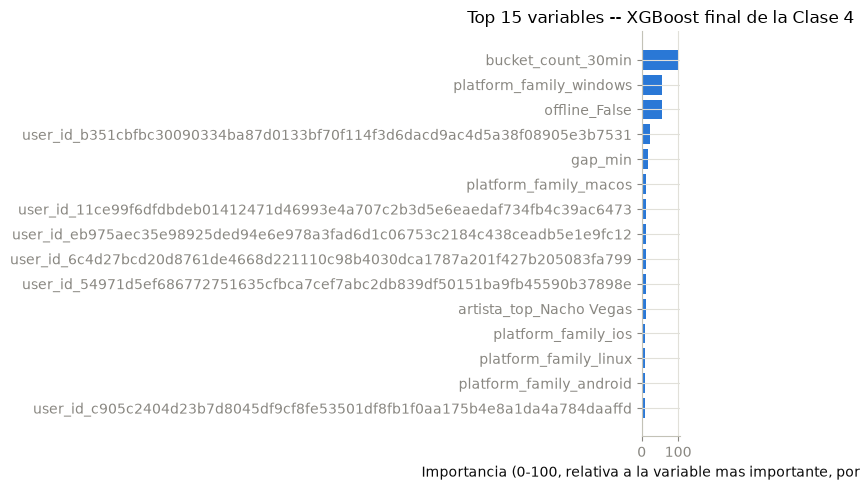

Variables usadas por el modelo: 88 de 128 columnas totales


In [21]:
importancias = booster_final.get_score(importance_type="gain")
imp_df = pd.DataFrame(list(importancias.items()), columns=["feature", "gain"]).sort_values("gain", ascending=False)
imp_df["gain_norm"] = 100 * imp_df["gain"] / imp_df["gain"].max()

top_n = 15
top_imp = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(top_imp["feature"], top_imp["gain_norm"], color=C_AZUL)
plt.xlabel("Importancia (0-100, relativa a la variable mas importante, por gain)")
plt.title(f"Top {top_n} variables -- XGBoost final de la Clase 4")
plt.tight_layout()
plt.show()

print(f"Variables usadas por el modelo: {len(imp_df)} de {len(names_ambos)} columnas totales")

### Modelo final: reentrenar con el 100% de los datos y submission

Misma práctica que en las Clases 1-3: el modelo que va a Kaggle se reentrena con el 100% de las filas de `train` (filtradas a `VENTANA_FINAL`), porque la validación ya cumplió su rol. La cantidad de árboles es `NROUNDS_FINAL` — la que fijó la CV del re-tuneo — y **no depende de `test_interno` en absoluto**. Detalle honesto: el train final tiene más filas que los folds de la CV, y con `eta` fijo el óptimo de rondas con más datos suele ser igual o apenas mayor — un número fijado por CV es levemente conservador, preferible a estimarlo mirando datos que no debemos usar para decidir.

Dos detalles de correctitud heredados de la Clase 3, y uno nuevo:

- **`gap_min`** en la primera fila de cada usuario de `test`: necesita el historial real que quedó en `train`, no el sentinela -1 (mismo truco de concatenar train+test, calcular, y quedarse solo con la porción de test).
- **`bucket_count_30min`**, **`pos_en_bucket`** y **`bucket_count_dia`**: autocontenidos en `test` — el corte train/test cae en un cambio de día calendario, ningún bloque de 30 min ni ningún día cruza la frontera.
- **`gap_siguiente`** (nuevo de esta clase): a diferencia de `gap_min`, **no** se calcula con continuidad hacia train — sería usar el futuro (test) para enriquecer una feature de una fila de train, que es un paso más allá de lo que ya validamos. Se calcula autocontenido dentro de `test` únicamente (para cualquier fila sin "próxima" reproducción dentro de test, sentinela -1, aunque en los datos reales sí haya una reproducción posterior — mismo tipo de aproximación conservadora que ya aceptamos en otros lados).

In [22]:
# Reconstruimos el 100% de train ya enriquecido (df_train + df_test_interno tienen todas
# las columnas nuevas: gap_min, bucket_count_30min, pos_en_bucket, bucket_count_dia, gap_siguiente).
train_completo = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
train_final_full = filtrar_reciente(train_completo, VENTANA_FINAL)

# Cargar test y aplicar las mismas derivaciones que en train (mismo TOP_ARTISTAS aprendido
# solo de train, para no filtrar informacion del test).
test_raw = pd.read_csv(
    f"{DATA_DIR}/test_data.txt", sep="\t",
    usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES, low_memory=False,
)
test_raw["content_type"] = np.select(
    [test_raw["spotify_track_uri"].notna(),
     test_raw["spotify_episode_uri"].notna(),
     test_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
test_raw["ts_dt"] = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
test_raw["hora"] = test_raw["ts_dt"].dt.hour
test_raw["dia_semana"] = test_raw["ts_dt"].dt.dayofweek.map(dict(enumerate(DIAS)))
test_raw["artista_top"] = test_raw[col_artista].where(test_raw[col_artista].isin(TOP_ARTISTAS), "otros")

# gap_min: recencia con continuidad real train->test (unico feature que la necesita)
combinado = pd.concat([
    train_completo[["obs_id", "user_id", "ts_dt"]],
    test_raw[["obs_id", "user_id", "ts_dt"]],
]).sort_values(["ts_dt", "obs_id"])
combinado["gap_min"] = combinado.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
gap_por_obs = combinado.set_index("obs_id")["gap_min"]
test_raw["gap_min"] = test_raw["obs_id"].map(gap_por_obs).fillna(-1)

# el resto, autocontenidos en test (ver razonamiento en la celda de arriba)
test_raw["bucket_count_30min"] = test_raw.groupby(["user_id", "ts"])["obs_id"].transform("size")
test_raw["pos_en_bucket"] = test_raw.groupby(["user_id", "ts"]).cumcount()
fecha_test = test_raw["ts_dt"].dt.floor("D")
test_raw["bucket_count_dia"] = test_raw.groupby(["user_id", fecha_test])["obs_id"].transform("size")
gap_sig_test = (test_raw.groupby("user_id")["ts_dt"].shift(-1) - test_raw["ts_dt"]).dt.total_seconds() / 60.0
test_raw["gap_siguiente"] = gap_sig_test.fillna(-1)

# Matriz sparse sobre la union train_final_full + test (mismo argumento de siempre: categorias
# son metadata, no fuga), despues partida por posicion. concat rellena "target" con NaN del
# lado de test -- no importa, esas posiciones nunca se usan (solo se lee y_ambos_kaggle[:n_tr_kaggle]).
df_ambos_kaggle = pd.concat([train_final_full, test_raw])
X_ambos_kaggle, y_ambos_kaggle, names_ambos_kaggle = build_sparse_matrix(df_ambos_kaggle, CAT_FINAL_2, NUM_FINAL_2)
n_tr_kaggle = len(train_final_full)
X_tr_kaggle = X_ambos_kaggle[:n_tr_kaggle]
y_tr_kaggle = y_ambos_kaggle[:n_tr_kaggle]
X_test_kaggle = X_ambos_kaggle[n_tr_kaggle:]

dtrain_kaggle = xgb.DMatrix(X_tr_kaggle, label=y_tr_kaggle, feature_names=names_ambos_kaggle)
dtest_kaggle = xgb.DMatrix(X_test_kaggle, feature_names=names_ambos_kaggle)

# Rondas fijadas por la CV (NROUNDS_FINAL) -- el modelo final no mira test_interno para nada.
modelo_final = xgb.train({**BASE_PARAMS_XGB, **PARAMS_FINAL}, dtrain_kaggle,
                         num_boost_round=NROUNDS_FINAL)
test_pred_proba = modelo_final.predict(dtest_kaggle)

submission_clase4 = pd.DataFrame({"obs_id": test_raw["obs_id"], "target": test_pred_proba})
submission_clase4.to_csv("../submissions/submission_clase4_xgboost.csv", index=False)
print("Guardado submission_clase4_xgboost.csv --", len(submission_clase4), "filas")
log_progreso(f"Submission guardada: submission_clase4_xgboost.csv ({len(submission_clase4)} filas, {NROUNDS_FINAL} rondas, train {n_tr_kaggle:,} filas)")
submission_clase4.head()

Guardado submission_clase4_xgboost.csv -- 51570 filas
[18:35:59] Submission guardada: submission_clase4_xgboost.csv (51570 filas, 222 rondas, train 218,339 filas)


,obs_id,target
0,911345,0.116856
1,911346,0.109965
2,911347,0.044401
3,911348,0.043532
4,911349,0.043298


### Notas honestas para el informe — Clase 4 (con los números de la corrida ejecutada)

- **Qué se agregó respecto de la Clase 3:** representación de categóricas como matrices ralas (`pd.get_dummies(sparse=True, dummy_na=True)` → CSR) y reemplazo del árbol por **XGBoost** (`xgb.train` + `DMatrix` + watchlist con logs en vivo + early stopping). Búsqueda de hiperparámetros en dos grillas conjuntas de 48 combos × 4 folds de la CV temporal heredada (una al migrar de modelo, otra de re-tuneo con el feature set cerrado), más un mini-refinamiento de borde. La ventana de datos se re-validó **dos veces** (al cambiar de modelo y al cierre con la receta final). Tres experimentos de features con el protocolo una-decisión-un-número de la Clase 3.
- **Receta final:** `max_depth=6, eta=0.05, min_child_weight=1, subsample=0.8, colsample_bytree=1.0, gamma=0`, **222 rondas** (promedio del early stopping en los folds de la CV), ventana 24 meses, 9 categóricas one-hot sparse + 6 numéricas (141 columnas). **AUC CV: 0.8368** vs. 0.8232 del árbol (+0.0136).
- **Comparación honesta en `test_interno` (única mirada): 0.8247 vs. 0.8093 del árbol (+0.0154).** Protocolo reforzado respecto de clases anteriores: las rondas van fijadas desde la CV, **sin early stopping contra `test_interno`** — si el corte se eligiera mirando `test_interno`, XGBoost tendría una ventaja adaptativa que el árbol no tuvo. La curva visible del watchlist muestra pico 0.8248 cerca de la ronda 175: el protocolo fijo costó ~0.0001 de AUC y compra una medición limpia.
- **Lo que sobrevivió (2 de 3 experimentos):** los tres conteos nuevos `pos_en_bucket` (+0.0007 solo), `bucket_count_dia` (+0.0008) y `gap_siguiente` (+0.0014) — juntos **+0.0028**, prácticamente aditivos (+0.0029 si no se pisaran nada); y `hora` como numérica en lugar del one-hot (+0.0002, misma AUC con 25 columnas menos). Sobre `gap_siguiente`: misma familia de legitimidad "batch" que `bucket_count_30min` (el test de Kaggle es un archivo estático con todos los `ts` a la vista) y misma honestidad — es estructura temporal, no comportamiento profundo; en el test de Kaggle se calcula autocontenido, sin puente hacia train.
- **Lo que se probó y se rechazó, con evidencia:** artista sin tope (15.941 categorías, −0.0010) y artista+canción sin tope (100.489 columnas totales, −0.0004; con `colsample=0.5`, −0.0000 = empate exacto). Las matrices ralas cumplen lo que promete la clase — 100k columnas nunca rompieron la memoria — pero cada evaluación pasa de ~15-30 segundos a ~33 minutos y el AUC no mejora: mismo veredicto que con el árbol en la Clase 3, ahora confirmado también para el ensamble. También quedó confirmado en las grillas que la profundidad 14 (óptima para el árbol *solo*) es lo **peor** para el ensamble — boosting prefiere árboles chicos que aprenden de a poco, tal cual la teoría de la clase — y que `min_child_weight=100` (el análogo del freno de hojas del árbol) acá sobra.
- **Corrección factual de paso:** los "18.543 artistas / 95.837 canciones" citados en las notas de la Clase 3 corresponden al archivo completo (911k filas); el `df_train` temporal tiene 15.941 / 84.436 — el 15% más reciente aporta ~2.600 artistas y ~11.400 canciones que el pasado no vio.
- **Honestidad sobre la CV:** los folds son heterogéneos (el más viejo ronda 0.78 de AUC, el tercero 0.885) — el promedio 0.8368 no es una promesa puntual. `test_interno` (0.8247) cae por debajo del promedio de la CV igual que pasó en la Clase 3 (0.8093 vs. 0.8232): la brecha es consistente entre clases, no un artefacto nuevo de XGBoost.
- **Pendiente que la propia clase sugiere "para el final":** probar LightGBM y promediar predicciones de modelos distintos — anotado para la etapa de cierre pre-entrega, no para ahora.
- **Submission:** `submission_clase4_xgboost.csv` (51.570 filas; modelo reentrenado con el 100% de train filtrado a 24 meses = 218.339 filas, 222 rondas). **Score público en Kaggle: 0.84541** — de nuevo por encima de la estimación honesta en test_interno (0.8247, +0.0207), misma brecha y misma explicación sana que en la Clase 3: el test real (sep-dic 2024) queda pegado al final del train y el modelo final entrena con datos hasta agosto 2024, mientras que la comparación interna entrena solo hasta mayo 2023 — el escenario real es más fácil que el de medición. Mejora clara sobre la Clase 3 (0.8289 → 0.84541).